In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Load Data

In [2]:
# Get root directory and data directory
PROJECT_ROOT = Path.cwd().resolve().parents[0]
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "retailhero_causal_forest_features.csv"

# Load data
processed_df = pd.read_csv(PROCESSED_DATA_PATH)

## ATE Benchmark 1: Unweighted (Difference-in-Means)

Function: compute_ate_benchmark

In [3]:
def compute_ate_benchmark(features: pd.DataFrame,
                          treatment_col: str = "treatment",
                          target_col: str = "target") -> dict:

    # Filter out treated and untreated columns
    treated = features.loc[features["treatment"] == 1, target_col]
    control = features.loc[features["treatment"] == 0, target_col]

    # Find the mean of (Y | T=1) and (Y | T=0)
    mean_treated = treated.mean()
    mean_control = control.mean()

    # Find ATE for entire population
    ate_hat = mean_treated - mean_control

    return {
        "n_treated": len(treated),
        "n_control": len(control),
        "mean_treated": mean_treated,
        "mean_control": mean_control,
        "ATE_benchmark": ate_hat
    }

Run benchmark and show results

In [4]:
print("=" * 60)
print("ATE Benchmark (simple difference in means)")
print("=" * 60)
results = compute_ate_benchmark(processed_df)
print(f"n_treated = {results['n_treated']}")
print(f"n_control = {results['n_control']}")
print(f"P(purchase | treated) = {results['mean_treated']:.4f}")
print(f"P(purchase | control) = {results['mean_control']:.4f}")
print(f"\nBenchmark ATE estimate = {results['ATE_benchmark']:.4f}")

ATE Benchmark (simple difference in means)
n_treated = 99981
n_control = 100058
P(purchase | treated) = 0.6365
P(purchase | control) = 0.6033

Benchmark ATE estimate = 0.0332


## ATE Benchmark 2: Density-Weighted (From X5 Paper)

Paper Default Parameters

In [5]:
N_LATENT_DIMS = 2   # Latent dimensionality used in the paper
N_GRID = 20    # 20x20 bins used in paper
MIN_BIN_COUNT = 1     # At least one of each (treated and control) per bin

Load features

In [6]:
covariate_cols = [
    c for c in processed_df.columns
    if c not in ("client_id", "treatment", "target")
]

print(f"Rows: {len(processed_df)}")
print(f"Covariates used for dimensionality reduction ({len(covariate_cols)}):")
print(covariate_cols)

processed_df.isna().sum()[processed_df.isna().sum() > 0]   # check for NaN values

Rows: 200039
Covariates used for dimensionality reduction (19):
['age', 'num_transactions', 'num_unique_products', 'num_stores_visited', 'total_quantity', 'avg_items_per_transaction', 'total_spend', 'avg_transaction_spend', 'median_transaction_spend', 'spend_std', 'regular_points_received', 'regular_points_spent', 'express_points_received', 'express_points_spent', 'net_regular_points_change', 'net_express_points_change', 'days_since_last_purchase', 'avg_days_between_transactions', 'customer_activity_span']


Series([], dtype: int64)

Step 1: Dimensionality Reduction (to 2D)

In [7]:
from scipy import stats
z_scores = np.abs(stats.zscore(processed_df[covariate_cols]))
outlier_mask = (z_scores > 5).any(axis=1)  # rows with any covariate >5 SDs from mean
print(f"Outliers: {outlier_mask.sum()} ({100*outlier_mask.mean():.2f}%)")

features_clean = processed_df[~outlier_mask].reset_index(drop=True)

Outliers: 9095 (4.55%)


In [8]:
def reduce_to_latent_space(features: pd.DataFrame, covariate_cols: list[str],
                            n_components: int = N_LATENT_DIMS) -> np.ndarray:
    X = features[covariate_cols].to_numpy()
    X_scaled = StandardScaler().fit_transform(X)
    latent = PCA(n_components=n_components, random_state=0).fit_transform(X_scaled)
    return latent


latent = reduce_to_latent_space(processed_df, covariate_cols)
latent.shape

(200039, 2)

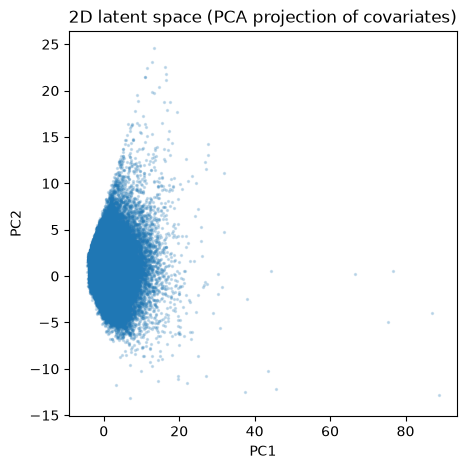

In [9]:
# To visualise the data points in a 2D space
plt.figure(figsize=(5, 5))
plt.scatter(latent[:, 0], latent[:, 1], s=2, alpha=0.2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D latent space (PCA projection of covariates)")
plt.show()

Step 2: Grid the latent space into 20x20

In [10]:
def assign_grid_bins(latent: np.ndarray, n_grid: int = N_GRID) -> np.ndarray:
    n_dims = latent.shape[1]
    bin_indices_per_dim = []

    for d in range(n_dims):
        edges = np.linspace(latent[:, d].min(), latent[:, d].max(), n_grid + 1)
        # np.digitize with inner edges only, so indices run 0..n_grid-1
        idx = np.digitize(latent[:, d], edges[1:-1])
        bin_indices_per_dim.append(idx)

    # Flatten multi-dimensional bin coordinates into a single integer bin id
    bin_id = np.zeros(len(latent), dtype=int)
    for d, idx in enumerate(bin_indices_per_dim):
        bin_id = bin_id * n_grid + idx

    return bin_id


features_binned = processed_df.copy()
features_binned["bin"] = assign_grid_bins(latent, n_grid=N_GRID)
features_binned[["bin"]].describe()

,bin
count,200039.000000
mean,14.741755
std,12.375608
min,4.000000
25%,6.000000
50%,7.000000
75%,26.000000
max,384.000000


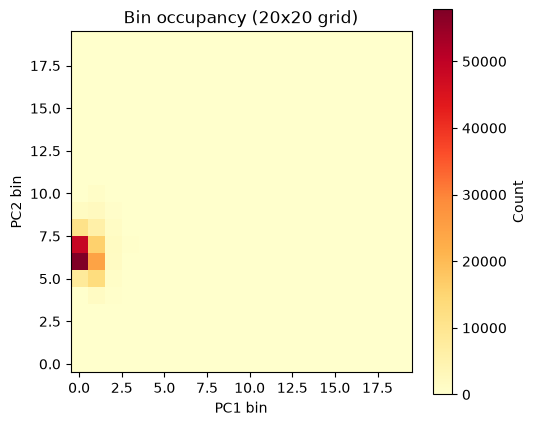

In [11]:
# Visualize bin occupancy (cf. paper's Fig. 11 / Fig. 17)
bin_2d = assign_grid_bins(latent, n_grid=N_GRID)
x_idx = np.digitize(latent[:, 0], np.linspace(latent[:, 0].min(), latent[:, 0].max(), N_GRID + 1)[1:-1])
y_idx = np.digitize(latent[:, 1], np.linspace(latent[:, 1].min(), latent[:, 1].max(), N_GRID + 1)[1:-1])

density_grid = np.zeros((N_GRID, N_GRID))
for xi, yi in zip(x_idx, y_idx):
    density_grid[yi, xi] += 1

plt.figure(figsize=(5.5, 5))
plt.imshow(density_grid, origin="lower", cmap="YlOrRd")
plt.colorbar(label="Count")
plt.title(f"Bin occupancy ({N_GRID}x{N_GRID} grid)")
plt.xlabel("PC1 bin")
plt.ylabel("PC2 bin")
plt.show()

Step 3: Density-Weighted ATE

In [12]:
def compute_ate_density_weighted(
    features: pd.DataFrame,
    covariate_cols: list[str],
    treatment_col: str = "treatment",
    target_col: str = "target",
    n_components: int = N_LATENT_DIMS,
    n_grid: int = N_GRID,
    min_bin_count: int = MIN_BIN_COUNT,
) -> dict:
    df = features.copy()

    latent = reduce_to_latent_space(df, covariate_cols, n_components=n_components)
    df["bin"] = assign_grid_bins(latent, n_grid=n_grid)

    n_total = len(df)
    total_bins_possible = n_grid ** n_components

    ate_terms = []
    bin_records = []
    n_bins_dropped = 0
    n_dropped_rows = 0

    for b, group in df.groupby("bin"):
        treated_y = group.loc[group[treatment_col] == 1, target_col]
        control_y = group.loc[group[treatment_col] == 0, target_col]

        if len(treated_y) < min_bin_count or len(control_y) < min_bin_count:
            n_bins_dropped += 1
            n_dropped_rows += len(group)
            continue

        p_b = len(group) / n_total
        local_uplift = treated_y.mean() - control_y.mean()
        contribution = p_b * local_uplift

        ate_terms.append(contribution)
        bin_records.append({
            "bin": b,
            "n_total": len(group),
            "n_treated": len(treated_y),
            "n_control": len(control_y),
            "p_b": p_b,
            "local_uplift": local_uplift,
            "contribution": contribution,
        })

    ate_hat = sum(ate_terms)

    return {
        "ate_hat": ate_hat,
        "n_bins_used": len(bin_records),
        "n_bins_possible": total_bins_possible,
        "n_bins_dropped": n_bins_dropped,
        "n_rows_dropped": n_dropped_rows,
        "pct_rows_dropped": 100 * n_dropped_rows / n_total,
        "bin_details": pd.DataFrame(bin_records),
    }


results = compute_ate_density_weighted(processed_df, covariate_cols)

print(f"Bins used: {results['n_bins_used']} / {results['n_bins_possible']} possible")
print(f"Bins dropped (too sparse): {results['n_bins_dropped']}")
print(f"Rows dropped: {results['n_rows_dropped']} ({results['pct_rows_dropped']:.2f}% of population)")
print(f"\nEq. (16) ATE estimate = {results['ate_hat']:.4f}")

Bins used: 73 / 400 possible
Bins dropped (too sparse): 44
Rows dropped: 63 (0.03% of population)

Eq. (16) ATE estimate = 0.0321


Inspect contributions per bin

In [13]:
bin_details = results["bin_details"].sort_values("contribution", ascending=False)
bin_details.head(10)

,bin,n_total,n_treated,n_control,p_b,local_uplift,contribution
2,6,57783,28756,29027,0.288859,0.044304,0.012798
3,7,48588,24200,24388,0.242893,0.043048,0.010456
1,5,8325,4212,4113,0.041617,0.038304,0.001594
12,27,15809,7901,7908,0.079030,0.017901,0.001415
4,8,11277,5577,5700,0.056374,0.024195,0.001364
11,26,24592,12328,12264,0.122936,0.009882,0.001215
13,28,5987,3030,2957,0.029929,0.032602,0.000976
25,48,1157,600,557,0.005784,0.085592,0.000495
10,25,12926,6500,6426,0.064617,0.007231,0.000467
14,29,2044,1033,1011,0.010218,0.044649,0.000456


Paper reports minimal dependence on the grid resolution, so perform checks by replicating 10x10 and 30x30 grids.

In [14]:
for n_grid in [10, 20, 30]:
    r = compute_ate_density_weighted(processed_df, covariate_cols, n_grid=n_grid)
    print(f"n_grid={n_grid:>2} -> ATE = {r['ate_hat']:.4f}  "
          f"(bins used: {r['n_bins_used']}/{r['n_bins_possible']}, "
          f"rows dropped: {r['pct_rows_dropped']:.2f}%)")

n_grid=10 -> ATE = 0.0324  (bins used: 30/100, rows dropped: 0.01%)
n_grid=20 -> ATE = 0.0321  (bins used: 73/400, rows dropped: 0.03%)
n_grid=30 -> ATE = 0.0318  (bins used: 127/900, rows dropped: 0.06%)
